In [1]:
!python -V

Python 3.13.9


In [2]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

In [17]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-02.parquet')

df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [18]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee,duration
0,2,2026-02-01 00:58:25,2026-02-01 01:03:26,N,1.0,82,129,1.0,0.50,6.50,...,1.80,0.0,NaN,1.0,10.80,1.0,1.0,0.0,0.00,5.016667
1,2,2026-02-01 00:05:50,2026-02-01 00:13:19,N,1.0,33,65,1.0,1.08,9.30,...,2.95,0.0,NaN,1.0,14.75,1.0,1.0,0.0,0.00,7.483333
2,1,2026-02-01 00:45:54,2026-02-01 01:28:27,N,5.0,226,143,1.0,5.20,75.00,...,22.70,0.0,NaN,0.0,98.45,1.0,2.0,0.0,0.75,42.550000
3,2,2026-02-01 00:06:38,2026-02-01 00:15:56,N,1.0,74,235,1.0,4.70,20.50,...,0.00,0.0,NaN,1.0,23.00,2.0,1.0,0.0,0.00,9.300000
4,2,2026-02-01 00:37:31,2026-02-01 00:51:10,N,1.0,120,119,1.0,2.47,16.30,...,0.00,0.0,NaN,1.0,18.80,2.0,1.0,0.0,0.00,13.650000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37368,6,2026-02-28 22:34:51,2026-02-28 23:07:47,None,NaN,246,248,NaN,11.93,3.00,...,0.00,0.0,NaN,0.3,31.93,NaN,NaN,NaN,0.00,32.933333
37369,2,2026-02-28 22:22:00,2026-02-28 22:48:00,None,NaN,92,265,NaN,7.64,32.28,...,0.00,0.0,NaN,1.0,33.78,NaN,NaN,NaN,0.00,26.000000
37370,6,2026-02-28 23:13:51,2026-02-28 23:55:20,None,NaN,19,117,NaN,12.33,3.00,...,0.00,0.0,NaN,0.3,36.69,NaN,NaN,NaN,0.00,41.483333
37371,2,2026-02-28 23:53:12,2026-03-01 00:27:55,None,NaN,97,262,NaN,9.54,52.18,...,6.00,0.0,NaN,1.0,62.43,NaN,NaN,NaN,0.00,34.716667


In [19]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

8.100501553302708

/tmp/ipykernel_10804/1672306066.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_10804/1672306066.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')


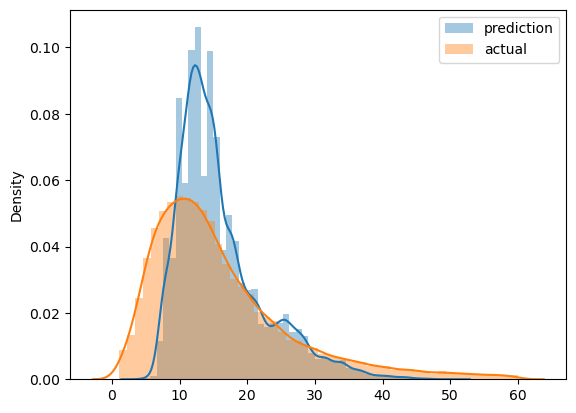

In [20]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')

plt.legend()

In [21]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID'] 
    df[categorical] = df[categorical].astype(str)
    
    return df

In [22]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-02.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2026-03.parquet')

In [23]:
len(df_train), len(df_val)

(35319, 41668)

In [24]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [25]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [26]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [38]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.070698109923191

/tmp/ipykernel_10804/2306935311.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_10804/2306935311.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')
/tmp/ipykernel_10804/2306935311.py:3: UserWarning: 

`distplot` is a deprec

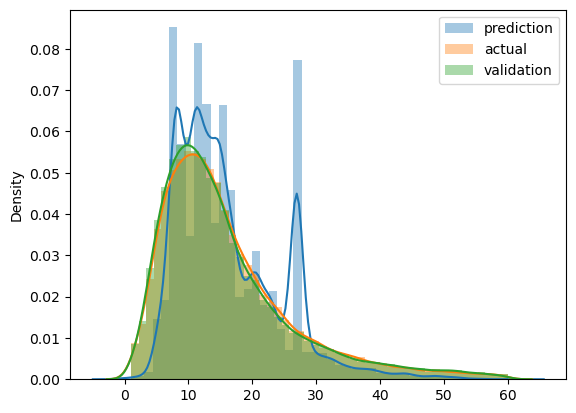

In [42]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
sns.distplot(y_val, label='validation')


plt.legend()

In [47]:
lr = Lasso(.0001)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.125525491553054

/tmp/ipykernel_10804/2306935311.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label='prediction')
/tmp/ipykernel_10804/2306935311.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train, label='actual')
/tmp/ipykernel_10804/2306935311.py:3: UserWarning: 

`distplot` is a deprec

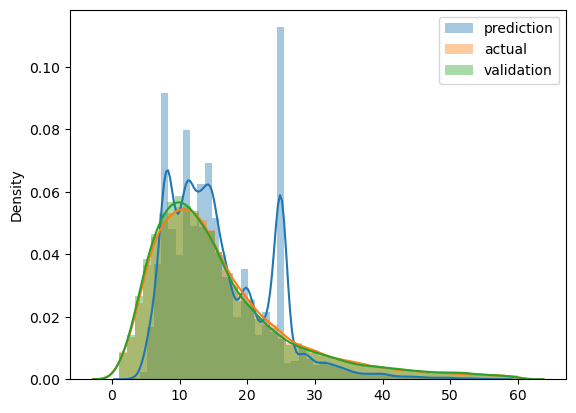

In [48]:
sns.distplot(y_pred, label='prediction')
sns.distplot(y_train, label='actual')
sns.distplot(y_val, label='validation')


plt.legend()